# Thesis Data Exploration — Normalised Energy Demand Overview

This notebook produces a **dataset-summary plot** in the style of *Estimation of Building Energy Demand Characteristics using Bayesian Statistics and Energy Signature Models* (Fig. 3).  
Daily heat-energy use for every campus building is **normalised to kWh/m³** so that buildings of different sizes can be compared directly.  
Cross-building daily statistics (min, Q1, median, mean, Q3, max) are then plotted as a band chart.

In [1]:
# Imports

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Project utilities
sys.path.insert(0, str(Path.cwd() / 'utils'))
from building_data_loader import (
    get_building_dataframe,
    load_campus_metadata,
    load_weather_dataframe,
)

## 1  Building metadata — volumes from EHR

Load `gross_volume_m3` for every campus building from the Estonian Building Register (EHR) summary.  
The `campus_code` column in the EHR file uses compound keys like `"U06 (+U06A)"`, so we extract the *first* code token to match the campus-data folder names.

In [2]:
ehr_df = pd.read_csv('data/ehr-building-data/ehr_building_summary.csv')

# Extract the first building code token (e.g. 'U06 (+U06A)' -> 'U06')
ehr_df['code'] = ehr_df['campus_code'].str.extract(r'^([A-Za-z0-9]+)')

volume_map = dict(zip(ehr_df['code'], ehr_df['gross_volume_m3']))

print('Building volumes (m3):')
for code, vol in sorted(volume_map.items()):
    print(f'  {code:6s}  {vol:>10,.0f}')

Building volumes (m3):
  GEO          3,875
  ICO         18,237
  ICT         44,730
  LIB         43,567
  NRG         25,240
  SOC         45,882
  STU             39
  TIM          4,140
  U01         21,780
  U02         24,136
  U03         30,456
  U04         24,521
  U04B         6,360
  U05         29,705
  U05B        11,539
  U06         61,946


## 2  Select buildings and load heating data

We include every building that has **heating energy readings** (`_measurement_delta_mwh`) and a valid `gross_volume_m3`.  
Buildings with only a main meter (`BHB01`) use that directly; buildings without `BHB01` (LIB, SOC, U02) have their **subsystem meters summed** to approximate total building heat demand.

Sub-buildings (U02B, U03B, U04B, U05B, U06A, U01U02, STU) are excluded to avoid double-counting or because they lack meaningful heating data.

In [3]:
# Buildings to include (main buildings only)
BUILDING_CODES = [
    'U01', 'U02', 'U03', 'U04', 'U05', 'U06',
    'GEO', 'NRG', 'LIB', 'SOC', 'ICO',
]

# Load metadata once for efficiency
overview_df, building_codes_df = load_campus_metadata()
weather_df = load_weather_dataframe()  # shared across all buildings

# --- Load each building and compute daily kWh/m3 ---
daily_kwh_m3 = {}  # building_code -> pd.Series indexed by date

for code in BUILDING_CODES:
    vol = volume_map.get(code)
    if vol is None or vol <= 0:
        print(f'!  {code}: no valid volume -- skipping')
        continue

    try:
        df = get_building_dataframe(
            code,
            overview_df=overview_df,
            building_codes_df=building_codes_df,
            weather_df=weather_df,
            include_weather=False,
            verbose=False,
        )
    except Exception as e:
        print(f'!  {code}: could not load -- {e}')
        continue

    # Find delta columns: *_measurement_delta_mwh
    delta_cols = [c for c in df.columns if c.endswith('_measurement_delta_mwh')]
    if not delta_cols:
        print(f'!  {code}: no delta columns -- skipping')
        continue

    # Prefer BHB01 (main meter) if it exists; otherwise sum all subsystems
    bhb01_cols = [c for c in delta_cols if c.startswith('bhb01')]
    if bhb01_cols:
        total_delta_mwh = df[bhb01_cols[0]].copy()
        meter_info = 'BHB01 (main meter)'
    else:
        total_delta_mwh = df[delta_cols].sum(axis=1)
        meter_info = f'sum of {len(delta_cols)} subsystems'

    # Build a temporary df with datetime + delta
    tmp = pd.DataFrame({
        'datetime': df['datetime'],
        'delta_mwh': total_delta_mwh,
    }).dropna(subset=['delta_mwh'])

    # Remove negative deltas (meter resets / anomalies)
    tmp = tmp[tmp['delta_mwh'] >= 0]

    # Resample to daily sum, MWh -> kWh, normalise by volume
    tmp = tmp.set_index('datetime')
    daily = tmp['delta_mwh'].resample('D').sum() * 1000  # MWh -> kWh
    daily = daily / vol  # kWh/m3/day

    # Drop days with zero data (no readings at all)
    daily = daily[daily > 0]

    daily_kwh_m3[code] = daily
    print(f'OK {code}: {len(daily):>5d} days  |  {meter_info}  |  vol = {vol:,.0f} m3')

print(f'\nLoaded {len(daily_kwh_m3)} buildings successfully.')

OK U01:   837 days  |  BHB01 (main meter)  |  vol = 21,780 m3
OK U02:   864 days  |  sum of 3 subsystems  |  vol = 24,136 m3
OK U03:   706 days  |  BHB01 (main meter)  |  vol = 30,456 m3
OK U04:   641 days  |  BHB01 (main meter)  |  vol = 24,521 m3
OK U05:   706 days  |  BHB01 (main meter)  |  vol = 29,705 m3
OK U06:   710 days  |  BHB01 (main meter)  |  vol = 61,946 m3
OK GEO:   204 days  |  BHB01 (main meter)  |  vol = 3,875 m3
!  NRG: could not load -- "None of ['Time'] are in the columns"
OK LIB:   756 days  |  sum of 3 subsystems  |  vol = 43,567 m3
OK SOC:   748 days  |  sum of 4 subsystems  |  vol = 45,882 m3
OK ICO:   921 days  |  BHB01 (main meter)  |  vol = 18,237 m3

Loaded 10 buildings successfully.


## 3  Outlier removal (3-sigma clipping)

Per building, any daily value beyond 3 standard deviations from the mean is replaced with NaN.  
This removes meter glitches and anomalous spikes that would compress the visual range of the plot.  
Applied iteratively (2 passes) so that extreme outliers don't inflate sigma on the first pass.

In [4]:
daily_kwh_m3_clean = {}
total_removed = 0

N_PASSES = 2  # iterative sigma-clipping

for code, series in daily_kwh_m3.items():
    clean = series.copy()
    n_removed_total = 0

    for p in range(N_PASSES):
        mu = clean.mean()
        sigma = clean.std()
        lower = mu - 3 * sigma
        upper = mu + 3 * sigma
        mask = (clean >= lower) & (clean <= upper)
        n_removed = (~mask).sum()
        n_removed_total += n_removed
        clean = clean[mask]

    total_removed += n_removed_total
    daily_kwh_m3_clean[code] = clean

    if n_removed_total > 0:
        print(f'  {code}: removed {n_removed_total} outlier(s)')

print(f'\nTotal outliers removed: {total_removed}')

  U01: removed 13 outlier(s)
  U02: removed 13 outlier(s)
  U05: removed 4 outlier(s)
  U06: removed 4 outlier(s)
  GEO: removed 5 outlier(s)
  LIB: removed 4 outlier(s)
  SOC: removed 6 outlier(s)
  ICO: removed 3 outlier(s)

Total outliers removed: 52


## 4  Cross-building daily statistics

For each calendar day, compute the **min, Q1, median, mean, Q3, max** of the normalised kWh/m3 values across all loaded buildings.  
This mirrors Fig. 3 in the reference paper.

In [5]:
# Combine all buildings into a single DataFrame (columns = buildings, index = date)
all_daily = pd.DataFrame(daily_kwh_m3_clean)

# Require at least 3 buildings reporting on a given day
valid_mask = all_daily.notna().sum(axis=1) >= 3
all_daily = all_daily[valid_mask]

stats = pd.DataFrame({
    'min':    all_daily.min(axis=1),
    'q1':     all_daily.quantile(0.25, axis=1),
    'median': all_daily.median(axis=1),
    'mean':   all_daily.mean(axis=1),
    'q3':     all_daily.quantile(0.75, axis=1),
    'max':    all_daily.max(axis=1),
})

print(f'Date range: {stats.index.min().date()} -> {stats.index.max().date()}')
print(f'Days with >= 3 buildings: {len(stats)}')
stats.describe().round(5)

Date range: 2022-01-01 -> 2024-12-31
Days with >= 3 buildings: 1059


,min,q1,median,mean,q3,max
count,1059.00000,1059.00000,1059.00000,1059.00000,1059.00000,1059.00000
mean,0.00866,0.02097,0.03041,0.03092,0.04051,0.05378
std,0.02058,0.02487,0.03033,0.02878,0.03618,0.04436
min,0.00000,0.00003,0.00005,0.00011,0.00011,0.00016
25%,0.00017,0.00091,0.00278,0.00376,0.00489,0.00987
50%,0.00137,0.01381,0.02389,0.02450,0.03277,0.04492
75%,0.00293,0.03125,0.04815,0.04954,0.06769,0.08776
max,0.13866,0.14625,0.16089,0.14971,0.16303,0.17204


## 5  Dataset overview plot — daily energy use (kWh/m\u00b3)

A band chart showing the distribution of normalised daily heat demand across the TalTech campus building stock.

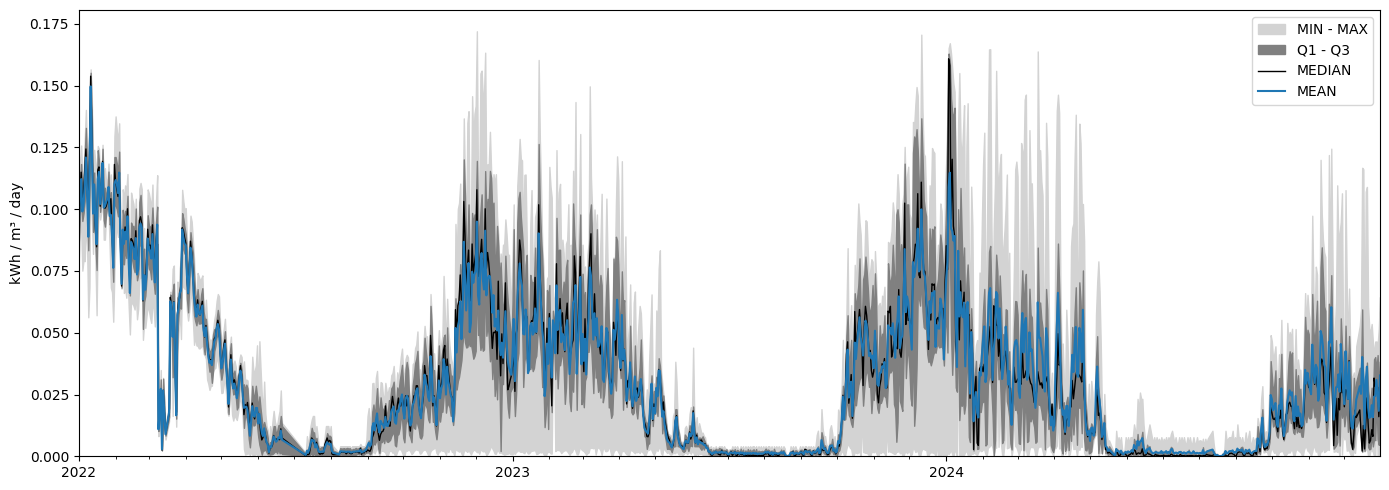

Figure saved: thesis_energy_overview.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

dates = stats.index

# Min-Max band
ax.fill_between(dates, stats['min'], stats['max'],
                color='lightgray', label='MIN - MAX')

# Q1-Q3 band (interquartile range)
ax.fill_between(dates, stats['q1'], stats['q3'],
                color='gray', label='Q1 - Q3')

# Median line
ax.plot(dates, stats['median'], color='black', linewidth=1, label='MEDIAN')

# Mean line (dashed)
ax.plot(dates, stats['mean'], label='MEAN')

# Formatting
ax.set_ylabel('kWh / m\u00b3 / day')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(dates.min(), dates.max())
ax.set_ylim(bottom=0)
ax.legend(loc='upper right')
# ax.set_title(
#    f'Daily heat energy use across the TalTech campus building stock '
#    f'({len(daily_kwh_m3_clean)} buildings, Jan 2022 \u2013 Dec 2024)'
#)

fig.tight_layout()
plt.savefig('thesis_energy_overview.png', dpi=200, bbox_inches='tight')
plt.show()

print('Figure saved: thesis_energy_overview.png')

## 6  Per-building summary statistics

A quick table of per-building annual statistics to complement the plot.

In [7]:
rows = []
for code, series in sorted(daily_kwh_m3_clean.items()):
    rows.append({
        'Building': code,
        'Volume (m3)': volume_map[code],
        'Days': len(series),
        'Mean (kWh/m3/day)': round(series.mean(), 5),
        'Median (kWh/m3/day)': round(series.median(), 5),
        'Max (kWh/m3/day)': round(series.max(), 5),
    })

summary_df = pd.DataFrame(rows).set_index('Building')
summary_df

,Volume (m3),Days,Mean (kWh/m3/day),Median (kWh/m3/day),Max (kWh/m3/day)
Building,,,,,
GEO,3875.0,199,0.02830,0.01032,0.12452
ICO,18237.2,918,0.01970,0.01651,0.07554
LIB,43567.0,752,0.02313,0.01610,0.09420
SOC,45882.4,742,0.04204,0.02872,0.17204
U01,21780.0,824,0.00159,0.00152,0.00519
U02,24136.0,851,0.01020,0.00456,0.04647
U03,30456.0,706,0.04988,0.04580,0.16089
U04,24521.0,641,0.05218,0.05302,0.16720
U05,29705.0,702,0.04445,0.03619,0.15385
